<a href="https://colab.research.google.com/github/josephineabioye/msc-skincare-reaction-prediction/blob/main/notebooks/04_modelling_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import userdata, drive
import os

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USERNAME = 'josephineabioye'
REPO_NAME = 'msc-skincare-reaction-prediction'

if not os.path.exists(REPO_NAME):
    !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
    %cd {REPO_NAME}
else:
    %cd {REPO_NAME}
    !git pull

!git config user.email "josephineabioye@yahoo.com"
!git config user.name "Josephine Abioye"

drive.mount('/content/drive', force_remount=False)

DRIVE_PROJECT = '/content/drive/MyDrive/msc-skincare-project'
DATA_RAW = f'{DRIVE_PROJECT}/data/raw'
DATA_PROCESSED = f'{DRIVE_PROJECT}/data/processed'

print(f"Working in: {os.getcwd()}")

Cloning into 'msc-skincare-reaction-prediction'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 131 (delta 71), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 350.53 KiB | 12.09 MiB/s, done.
Resolving deltas: 100% (71/71), done.
/content/msc-skincare-reaction-prediction
Mounted at /content/drive
Working in: /content/msc-skincare-reaction-prediction


Notebook Overview

In [9]:
# filters the dataset to skincare products, removes multi-product entries, cleans and standardises the ingredient names,
# and create a set of unique ingredients for each product.
import pandas as pd, ast, re

# Load the product information and keep only skincare products
products = pd.read_csv(f"{DATA_RAW}/product_info.csv")
skincare = products[products['primary_category'] == 'Skincare'].copy()

# Remove multi-product entries
has_ingredients = skincare[skincare['ingredients'].notna()]
is_multivariant = has_ingredients['ingredients'].str.contains(":'", regex=False)
single_products = has_ingredients[~is_multivariant].copy()
print("Single-product entries:", single_products.shape[0])

# Clean and convert each product's ingredient list into a set of ingredients
def parse_ingredients(raw):
    try:
        parts = ast.literal_eval(raw)
    except Exception:
        parts = [str(raw)]
    if not isinstance(parts, list):
        parts = [str(parts)]
    text = " , ".join(str(p) for p in parts)
    toks = set()
    for t in text.split(","):
        t = re.sub(r"\(.*?\)", " ", t)                # Remove additional notes in brackets
        t = re.sub(r"[^A-Za-z0-9\- ]", " ", t)        # Remove unnecessary punctuation
        t = re.sub(r"\s+", " ", t).strip().lower()    # Standardise spacing and convert ingredient names to lowercase
        if len(t) > 1:
            toks.add(t)
    return toks or None

# Apply the ingredient cleaning to all single-product entries
single_products["ing_set"] = single_products["ingredients"].apply(parse_ingredients)

# Keep products where the ingredient list was successfully parsed
prod = single_products[single_products["ing_set"].notna()].copy()

print("products with parsed ingredients:", prod["product_id"].nunique())
print("unique ingredient tokens:", len(set().union(*prod["ing_set"])))

Single-product entries: 2069
products with parsed ingredients: 2069
unique ingredient tokens: 5468


In [10]:
# keep ingredients appearing in at least five products, count ingredient frequency, converts the product ingredients into a sparse multi-hot feature matrix,
# and links the ingredient features to the labelled reviews.
from collections import Counter
import numpy as np
from scipy import sparse

# 1. Ingredient frequency (how many products each ingredient appears in)
df_counter = Counter()
for s in prod["ing_set"]:
    df_counter.update(s)

MIN_DF = 5   # Keep ingredients that appear in at least 5 products

vocab = sorted(ing for ing, c in df_counter.items() if c >= MIN_DF)
vocab_index = {ing: i for i, ing in enumerate(vocab)}
print(f"features kept: {len(vocab)} of {len(df_counter)} (MIN_DF={MIN_DF})")

# 2. Create a product-level multi-hot sparse matrix that shows whether each ingredient
# is present in each product.
prod = prod.reset_index(drop=True)
rows, cols = [], []
for r, s in enumerate(prod["ing_set"]):
    for ing in s:
        j = vocab_index.get(ing)
        if j is not None:
            rows.append(r); cols.append(j)
X_prod = sparse.csr_matrix((np.ones(len(rows), dtype=np.int8), (rows, cols)),
                           shape=(len(prod), len(vocab)))

# Map each product ID and its row in the ingredient matrix
pid_to_row = {pid: r for r, pid in enumerate(prod["product_id"])}

# 3. join to the labelled reviews (inner join on product_id) and keep the fields needed for the analysis
reviews = pd.read_parquet(f"{DATA_PROCESSED}/skincare_reviews_labelled.parquet",
                          columns=["product_id", "reaction_label", "skin_type", "skin_tone"])

# Keep only reviews for products that have usable ingredient information
reviews = reviews[reviews["product_id"].isin(pid_to_row)].reset_index(drop=True)

# Match each review to the corresponding product row in the ingredient matrix
row_idx = reviews["product_id"].map(pid_to_row).to_numpy()
X = X_prod[row_idx]                              # review-level ingredient matrix using the product ingredients
y = reviews["reaction_label"].to_numpy()         # Store the reaction labels for the reviews

# Keep product IDs so that reviews from the same product can be kept together or the by-product split
groups = reviews["product_id"].to_numpy()

print("reviews kept:", X.shape[0], "| features:", X.shape[1])
print("positives:", int(y.sum()), f"({y.mean():.3f})")

features kept: 1710 of 5468 (MIN_DF=5)
reviews kept: 1040578 | features: 1710
positives: 115466 (0.111)


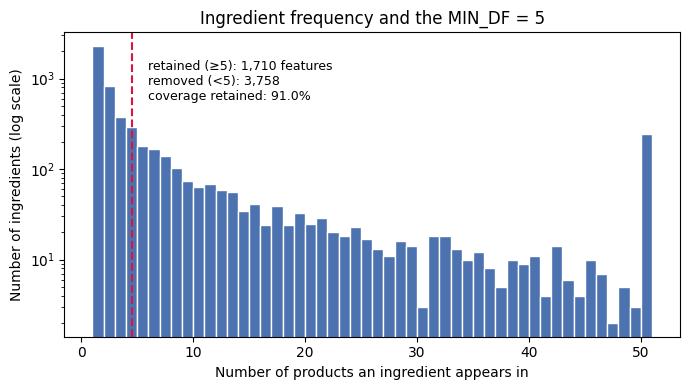

retained 1,710 | removed 3,758 | coverage 91.0%


In [ ]:
# Graphical representation of ingredient occurrences retained after filtering
import matplotlib.pyplot as plt
import numpy as np

dfvals   = np.array(list(df_counter.values()))
kept     = int((dfvals >= MIN_DF).sum())
removed  = int((dfvals <  MIN_DF).sum())
coverage = dfvals[dfvals >= MIN_DF].sum() / dfvals.sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.clip(dfvals, 1, 50), bins=range(1, 52), color="#4C72B0", edgecolor="white")
ax.axvline(MIN_DF - 0.5, color="crimson", linestyle="--", linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("Number of products an ingredient appears in")
ax.set_ylabel("Number of ingredients (log scale)")
ax.set_title(f"Ingredient frequency and the MIN_DF = {MIN_DF}")
ax.text(MIN_DF + 1, ax.get_ylim()[1] * 0.5,
        f"retained (≥{MIN_DF}): {kept:,} features\nremoved (<{MIN_DF}): {removed:,}\ncoverage retained: {coverage:.1%}",
        fontsize=9, va="top")
plt.tight_layout()
plt.savefig(f"{DATA_PROCESSED}/min_df_cut_fig.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"retained {kept:,} | removed {removed:,} | coverage {coverage:.1%}")

In [ ]:
#Split to train and test sets by product using 80%(Train) 20%(Test)
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("train:", X_train.shape[0], "| test:", X_test.shape[0])
print("train positive reactions:", round(y_train.mean(), 3), "| test positive reactions:", round(y_test.mean(), 3))
assert set(groups[train_idx]).isdisjoint(set(groups[test_idx]))
print("no product appears in both train and test")

train: 832205 | test: 208373
train positive reactions: 0.111 | test positive reactions: 0.112
no product appears in both train and test


In [11]:
# Convert allergens from Warshaw et al. (2015) to their INCI ingredient tokens, check which are present in the product dataset.
# The identified ingredients form the BLACKLIST used in the reaction-labelling analysis.
import pandas as pd

# Warshaw et al. (2015) allergens -> INCI ingredient tokens
warshaw_inci = {
    "fragrance mix I":        ["eugenol","geraniol","hydroxycitronellal","cinnamal",
                               "cinnamyl alcohol","isoeugenol","amyl cinnamal","evernia prunastri"],
    "MCI/MI":                 ["methylisothiazolinone","methylchloroisothiazolinone"],
    "lanolin alcohol":        ["lanolin","lanolin alcohol"],
    "cinnamic aldehyde":      ["cinnamal"],
    "paraben mix":            ["methylparaben","ethylparaben","propylparaben","butylparaben","isobutylparaben"],
    "glutaral":               ["glutaral","glutaraldehyde"],
    "formaldehyde-releasers": ["formaldehyde","quaternium-15","diazolidinyl urea",
                               "imidazolidinyl urea","dmdm hydantoin","2-bromo-2-nitropropane-1,3-diol"],
}

rows = []
BLACKLIST = set()
for allergen, incis in warshaw_inci.items():
    present = {i: df_counter.get(i, 0) for i in incis if df_counter.get(i, 0) > 0}
    absent  = [i for i in incis if df_counter.get(i, 0) == 0]
    BLACKLIST |= set(present)
    rows.append({
        "Warshaw allergen": allergen,
        "INCI tokens & (product count)": ", ".join(f"{k} ({v})" for k, v in present.items()) or "—",
        "Absent from dataset": ", ".join(absent) or "—",
    })

blacklist_table = pd.DataFrame(rows)

print("Final BLACKLIST size:", len(BLACKLIST))
print("BLACKLIST:", sorted(BLACKLIST), "\n")
blacklist_table

Final BLACKLIST size: 16
BLACKLIST: ['amyl cinnamal', 'butylparaben', 'cinnamal', 'cinnamyl alcohol', 'diazolidinyl urea', 'ethylparaben', 'eugenol', 'geraniol', 'glutaral', 'hydroxycitronellal', 'lanolin', 'lanolin alcohol', 'methylchloroisothiazolinone', 'methylisothiazolinone', 'methylparaben', 'propylparaben'] 



,Warshaw allergen,INCI tokens & (product count),Absent from dataset
0,fragrance mix I,"eugenol (40), geraniol (261), hydroxycitronell...","isoeugenol, evernia prunastri"
1,MCI/MI,"methylisothiazolinone (10), methylchloroisothi...",—
2,lanolin alcohol,"lanolin (2), lanolin alcohol (8)",—
3,cinnamic aldehyde,cinnamal (3),—
4,paraben mix,"methylparaben (52), ethylparaben (9), propylpa...",isobutylparaben
5,glutaral,glutaral (2),glutaraldehyde
6,formaldehyde-releasers,diazolidinyl urea (8),"formaldehyde, quaternium-15, imidazolidinyl ur..."


In [ ]:
# Apply allergen blacklist, tests it on the held-out reviews, and
# evaluates how well it predicts the manually assigned reaction labels using accuracy, precision, recall, F1, AUC-ROC, and a confusion matrix.
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# positive if ingredients intersect the blacklist
prod["bl_hit"] = prod["ing_set"].apply(lambda s: int(len(s & BLACKLIST) > 0))
pid_to_hit = dict(zip(prod["product_id"], prod["bl_hit"]))
bl_pred_all = reviews["product_id"].map(pid_to_hit).to_numpy()

y_pred = bl_pred_all[test_idx]
y_true = y_test

print("Blacklist flags", f"{prod['bl_hit'].mean():.1%}", "of products")
print("predicted-positive share of (test):", round(y_pred.mean(), 3))
print()
print("Accuracy :", round(accuracy_score(y_true, y_pred), 3),
      "| majority-class baseline:", round(1 - y_true.mean(), 3))
print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 3))
print("F1       :", round(f1_score(y_true, y_pred, zero_division=0), 3))
print("AUC-ROC  :", round(roc_auc_score(y_true, y_pred), 3), "(hard rule, so limited)")
print("\nConfusion matrix [rows = true 0/1, cols = pred 0/1]:")
print(confusion_matrix(y_true, y_pred))

Blacklist flags 17.2% of products
predicted-positive share of (test): 0.157

Accuracy : 0.762 | majority-class baseline: 0.888
Precision: 0.1
Recall   : 0.139
F1       : 0.116
AUC-ROC  : 0.49 (hard rule, so limited)

Confusion matrix [rows = true 0/1, cols = pred 0/1]:
[[155545  29432]
 [ 20141   3255]]


In [ ]:
# Logistical Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
import numpy as np

# Apply grouped CV on the training data only
gkf = GroupKFold(n_splits=5)

lr = LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=1000)
param_grid = {"C": [0.01, 0.1, 1, 10]}

search = GridSearchCV(
    lr,
    param_grid,
    scoring="f1",
    cv=gkf,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train, groups=groups[train_idx])

print("Best C:", search.best_params_["C"])
print("Best CV F1:", round(search.best_score_, 4))

best_lr = search.best_estimator_

# Evaluate once on the held-out test set
y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test)[:, 1]

print("\nTest-set performance")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1       :", round(f1_score(y_test, y_pred), 4))
print("AUC-ROC  :", round(roc_auc_score(y_test, y_prob), 4))
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, y_pred))

# Most influential ingredients by fitted coefficient
coefs = best_lr.coef_.ravel()
vocab_arr = np.array(vocab)
order = np.argsort(coefs)

print("\nTop 20 ingredients raising predicted reaction probability:")
for i in order[::-1][:20]:
    print(f"  {vocab_arr[i]:<30} {coefs[i]:+.3f}")

print("\nTop 20 ingredients lowering predicted reaction probability:")
for i in order[:20]:
    print(f"  {vocab_arr[i]:<30} {coefs[i]:+.3f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best C: 0.01
Best CV F1: 0.2141

Test-set performance
Accuracy : 0.5743
Precision: 0.1301
Recall   : 0.4911
F1       : 0.2057
AUC-ROC  : 0.5635
Confusion matrix [[TN, FP], [FN, TP]]:
[[108172  76805]
 [ 11907  11489]]

Top 20 ingredients raising predicted reaction probability:
  lactobacillus pumpkin fruit ferment filtrate +0.566
  paraffin                       +0.492
  hamamelis virginiana           +0.469
  ascorbic acid                  +0.447
  jasminum sambac flower extract +0.443
  chlorella protothecoides oil   +0.439
  cannabis sativa seed oil       +0.380
  resveratrol                    +0.377
  hydroxyphenyl propamidobenzoic acid +0.375
  pyridoxine hcl                 +0.370
  microcitrus australasica fruit extract +0.360
  isomalt                        +0.360
  hydrogenated poly              +0.344
  paeonia suffruticosa root extract +0.331
  helianthus annuus seed wax     +0.330
  glucomannan                   

In [ ]:
# Save the logistic regression predictions and predicted probabilities
lr_pred = y_pred.copy()
lr_prob = y_prob.copy()

In [ ]:
# XGBOOST Predictions
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

y_tr = np.asarray(y_train)
gtr = groups[train_idx]

neg, pos = np.bincount(y_tr)
spw = neg / pos
print("scale_pos_weight:", round(spw, 2))

base = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    scale_pos_weight=spw,
    n_estimators=300,
    n_jobs=-1,
    random_state=42,
)

param_dist = {
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.02, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "reg_lambda": [1.0, 5.0, 10.0],
    "reg_alpha": [0.0, 0.5, 1.0],
}

search = RandomizedSearchCV(
    base, param_dist, n_iter=20, scoring="f1",
    cv=GroupKFold(n_splits=3), n_jobs=-1, verbose=1, random_state=42,
)
search.fit(X_train, y_tr, groups=gtr)

print("Best params:", search.best_params_)
print("Best CV F1:", round(search.best_score_, 4))

# Refit best config with early stopping on a grouped validation split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
sub_tr, sub_val = next(gss.split(X_train, y_tr, gtr))

final = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    scale_pos_weight=spw,
    n_estimators=1000,
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42,
    **search.best_params_,
)
final.fit(X_train[sub_tr], y_tr[sub_tr],
          eval_set=[(X_train[sub_val], y_tr[sub_val])], verbose=False)
print("Best n_estimators (early stopping):", final.best_iteration + 1)

# Evaluate once on the held-out test set
y_pred = final.predict(X_test)
y_prob = final.predict_proba(X_test)[:, 1]
xgb_pred, xgb_prob = y_pred.copy(), y_prob.copy()

print("\nTest-set performance")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1       :", round(f1_score(y_test, y_pred), 4))
print("AUC-ROC  :", round(roc_auc_score(y_test, y_prob), 4))
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, y_pred))

# Top ingredients by gain importance
imp = final.feature_importances_
order = np.argsort(imp)[::-1][:20]
vocab_arr = np.array(vocab)
print("\nTop 20 ingredients by importance:")
for i in order:
    print(f"  {vocab_arr[i]:<30} {imp[i]:.4f}")

scale_pos_weight: 8.04
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 0.5, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV F1: 0.2259
Best n_estimators (early stopping): 158

Test-set performance
Accuracy : 0.6421
Precision: 0.1396
Recall   : 0.4234
F1       : 0.2099
AUC-ROC  : 0.5654
Confusion matrix [[TN, FP], [FN, TP]]:
[[123892  61085]
 [ 13489   9907]]

Top 20 ingredients by importance:
  salicylic acid                 0.0150
  sigesbeckia orientalis extract 0.0146
  saccharomyces cerevisiae extract 0.0141
  madecassic acid                0.0127
  coccinia indica fruit extract  0.0110
  glycolic acid                  0.0106
  cocamidopropyl dimethylamine   0.0106
  cocamidopropyl hydroxysultaine 0.0099
  synthetic wax                  0.0098
  coconut alkanes                0.0094
  sclerocarya birrea seed oil    0.0088
  sodium metabisulfite           0.00

In [12]:
np.savez(f"{DATA_PROCESSED}/test_predictions.npz",
         y_test=np.asarray(y_test), test_idx=test_idx,
         lr_pred=lr_pred, lr_prob=lr_prob, xgb_pred=xgb_pred, xgb_prob=xgb_prob)

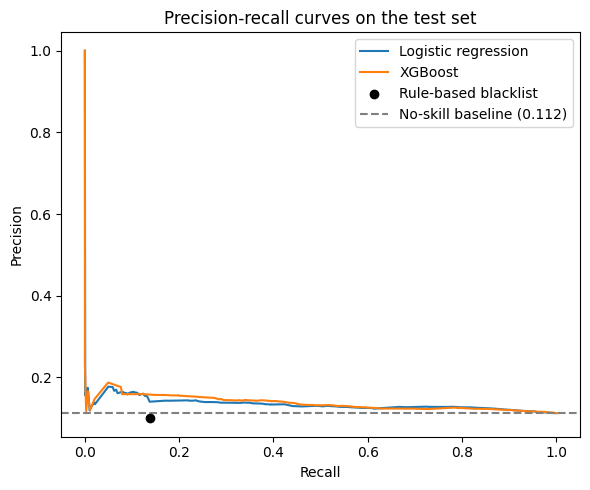

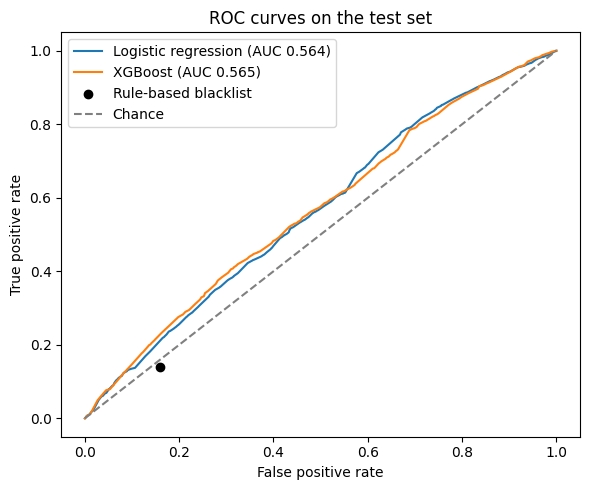

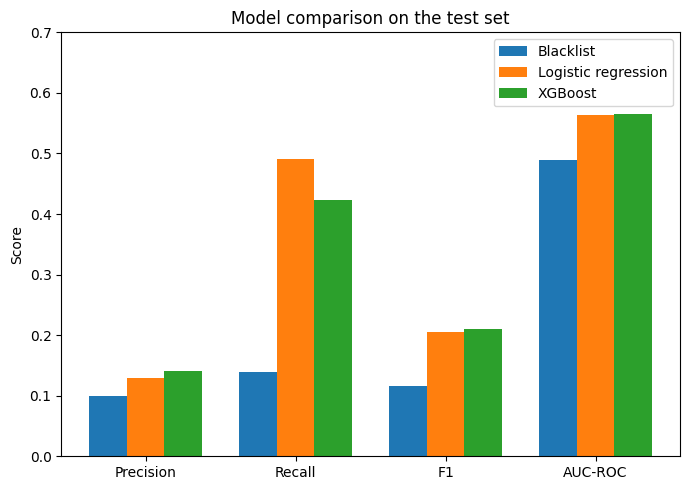

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_recall_curve, roc_curve, roc_auc_score,
                             precision_score, recall_score, confusion_matrix)

y_t = np.asarray(y_test)
prevalence = y_t.mean()

# Blacklist operating point
try:
    bl_prec = precision_score(y_t, bl_pred)
    bl_rec  = recall_score(y_t, bl_pred)
    tn, fp, fn, tp = confusion_matrix(y_t, bl_pred).ravel()
    bl_fpr, bl_tpr = fp/(fp+tn), tp/(tp+fn)
except NameError:
    # fallback to the recorded blacklist test confusion matrix
    tn, fp, fn, tp = 155545, 29432, 20141, 3255
    bl_prec, bl_rec = tp/(tp+fp), tp/(tp+fn)
    bl_fpr, bl_tpr = fp/(fp+tn), tp/(tp+fn)

# Precision-Recall
p_lr, r_lr, _ = precision_recall_curve(y_t, lr_prob)
p_xg, r_xg, _ = precision_recall_curve(y_t, xgb_prob)
plt.figure(figsize=(6,5))
plt.plot(r_lr, p_lr, label="Logistic regression")
plt.plot(r_xg, p_xg, label="XGBoost")
plt.scatter([bl_rec], [bl_prec], color="black", zorder=5, label="Rule-based blacklist")
plt.axhline(prevalence, ls="--", color="grey", label=f"No-skill baseline ({prevalence:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-recall curves on the test set")
plt.legend(); plt.tight_layout(); plt.savefig("fig_pr_curves.png", dpi=150); plt.show()

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_t, lr_prob)
fpr_xg, tpr_xg, _ = roc_curve(y_t, xgb_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic regression (AUC {roc_auc_score(y_t, lr_prob):.3f})")
plt.plot(fpr_xg, tpr_xg, label=f"XGBoost (AUC {roc_auc_score(y_t, xgb_prob):.3f})")
plt.scatter([bl_fpr], [bl_tpr], color="black", zorder=5, label="Rule-based blacklist")
plt.plot([0,1], [0,1], ls="--", color="grey", label="Chance")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curves on the test set")
plt.legend(); plt.tight_layout(); plt.savefig("fig_roc_curves.png", dpi=150); plt.show()

# Metric comparison bar chart
models  = ["Blacklist", "Logistic regression", "XGBoost"]
metrics = ["Precision", "Recall", "F1", "AUC-ROC"]
vals = np.array([
    [0.100, 0.139, 0.116, 0.490],   # blacklist
    [0.130, 0.491, 0.206, 0.564],   # logistic regression
    [0.140, 0.423, 0.210, 0.565],   # XGBoost
])
x = np.arange(len(metrics)); w = 0.25
plt.figure(figsize=(7,5))
for i, m in enumerate(models):
    plt.bar(x + (i-1)*w, vals[i], width=w, label=m)
plt.xticks(x, metrics); plt.ylabel("Score"); plt.ylim(0, 0.7)
plt.title("Model comparison on the test set")
plt.legend(); plt.tight_layout(); plt.savefig("fig_model_comparison.png", dpi=150); plt.show()

In [ ]:
print("aligned:", len(reviews) == X.shape[0],
      "| has cols:", {"skin_type", "skin_tone"}.issubset(reviews.columns))

aligned: True | has cols: True


In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

y_t = np.asarray(y_test)

demo = reviews.iloc[test_idx].reset_index(drop=True)
skin_type = demo["skin_type"].to_numpy()
tone_raw  = demo["skin_tone"]

tone_bands = {
    "porcelain":"Fair/Light","fair":"Fair/Light","fairLight":"Fair/Light","light":"Fair/Light",
    "lightMedium":"Light-Medium","medium":"Light-Medium",
    "mediumTan":"Medium-Tan","tan":"Medium-Tan","olive":"Medium-Tan",
    "deep":"Deep/Dark","rich":"Deep/Dark","dark":"Deep/Dark","ebony":"Deep/Dark",
}
band = tone_raw.map(tone_bands).to_numpy()

def metrics_for(mask, pred, prob):
    yt = y_t[mask]; yp = np.asarray(pred)[mask]; pr = np.asarray(prob)[mask]
    n = int(mask.sum()); pos = int(yt.sum())
    auc = roc_auc_score(yt, pr) if (0 < pos < n) else np.nan
    return {"n": n, "positives": pos,
            "pos_rate": round(pos/n, 4) if n else np.nan,
            "precision": round(precision_score(yt, yp, zero_division=0), 4),
            "recall":    round(recall_score(yt, yp, zero_division=0), 4),
            "f1":        round(f1_score(yt, yp, zero_division=0), 4),
            "auc":       round(auc, 4) if auc == auc else np.nan}

def disaggregate(values, order, pred, prob, label):
    rows = [{"group": g, **metrics_for(values == g, pred, prob)} for g in order]
    df = pd.DataFrame(rows)
    print(f"\n {label}")
    print(df.to_string(index=False))
    return df

type_order = ["dry", "oily", "combination", "normal"]
band_order = ["Fair/Light", "Light-Medium", "Medium-Tan", "Deep/Dark"]

for name, pred, prob in [("Logistic regression", lr_pred, lr_prob),
                         ("XGBoost", xgb_pred, xgb_prob)]:
    disaggregate(skin_type, type_order, pred, prob, f"{name} - by skin type")
    disaggregate(band, band_order, pred, prob, f"{name} - by skin tone band")


 Logistic regression - by skin type
      group      n  positives  pos_rate  precision  recall     f1    auc
        dry  34905       4044    0.1159     0.1380  0.4960 0.2159 0.5693
       oily  23532       2919    0.1240     0.1401  0.5002 0.2189 0.5654
combination 104569      11585    0.1108     0.1285  0.4990 0.2043 0.5635
     normal  24956       2409    0.0965     0.1150  0.4840 0.1859 0.5695

 Logistic regression - by skin tone band
       group      n  positives  pos_rate  precision  recall     f1    auc
  Fair/Light 102384      11730    0.1146     0.1346  0.5038 0.2124 0.5668
Light-Medium  51788       5389    0.1041     0.1198  0.4947 0.1929 0.5639
  Medium-Tan  18540       2046    0.1104     0.1333  0.5303 0.2130 0.5790
   Deep/Dark   4970        501    0.1008     0.1159  0.5030 0.1884 0.5691

 XGBoost - by skin type
      group      n  positives  pos_rate  precision  recall     f1    auc
        dry  34905       4044    0.1159     0.1488  0.4525 0.2239 0.5738
       oily  23

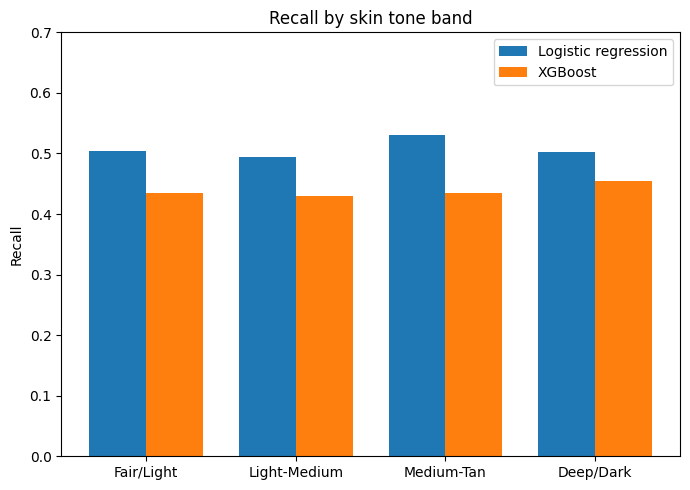

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import recall_score

bands = ["Fair/Light", "Light-Medium", "Medium-Tan", "Deep/Dark"]
rec = lambda pred: [recall_score(y_t[band==b], np.asarray(pred)[band==b], zero_division=0) for b in bands]
lr_r, xg_r = rec(lr_pred), rec(xgb_pred)

x = np.arange(len(bands)); w = 0.38
plt.figure(figsize=(7,5))
plt.bar(x - w/2, lr_r, w, label="Logistic regression")
plt.bar(x + w/2, xg_r, w, label="XGBoost")
plt.xticks(x, bands); plt.ylabel("Recall"); plt.ylim(0, 0.7)
plt.title("Recall by skin tone band")
plt.legend(); plt.tight_layout(); plt.savefig("fig_fairness_recall.png", dpi=150); plt.show()

In [13]:
d = np.load(f"{DATA_PROCESSED}/test_predictions.npz")
y_test   = d["y_test"]
test_idx = d["test_idx"]
lr_pred  = d["lr_pred"];  lr_prob  = d["lr_prob"]
xgb_pred = d["xgb_pred"]; xgb_prob = d["xgb_prob"]

In [14]:
# Error Analysis from Results of Logistic Regression Model (Best Model Based on Recall)
import numpy as np

TEXT_COL = "review_full"
MODEL_PRED = lr_pred        # or xgb_pred for the XGBoost Model Result

rt = pd.read_parquet(f"{DATA_PROCESSED}/skincare_reviews_labelled.parquet",
                     columns=["product_id", TEXT_COL])
rt = rt[rt["product_id"].isin(pid_to_row)].reset_index(drop=True)
assert (rt["product_id"].to_numpy() == reviews["product_id"].to_numpy()).all(), "misaligned"
text_test = rt[TEXT_COL].to_numpy()[test_idx]

y_t  = np.asarray(y_test)
yhat = np.asarray(MODEL_PRED)
fn_mask = (y_t == 1) & (yhat == 0)   # missed reactions
fp_mask = (y_t == 0) & (yhat == 1)   # false alarms
print("false negatives:", int(fn_mask.sum()), "| false positives:", int(fp_mask.sum()))

rng = np.random.default_rng(42)
def show(mask, k):
    for i in rng.choice(np.where(mask)[0], size=min(k, int(mask.sum())), replace=False):
        print(f"\n[label={y_t[i]} pred={yhat[i]}]\n{str(text_test[i])[:450]}")

print("\nMISSED REACTIONS (false negatives)")
show(fn_mask, 30)
print("\nFALSE ALARMS (false positives)")
show(fp_mask, 20)

false negatives: 11907 | false positives: 76805

MISSED REACTIONS (false negatives)

[label=1 pred=0]
VITAMIN C FOR THE EYES. The texture of this product is a mix between rich cream and serum. It is very soft and absorbs quickly too. It feels very smooth and silky when applying it and a little goes the long way. I definitely felt the burning sensation first couple days of use but then it slowly went away as my skin started tolerating it. It lighted my dark circles in just about a week of use. I will continue to use this product as I definitely th

[label=1 pred=0]
surprise! it's awesome!. Honestly, for such sensitive skin I have, I was really apprehensive about using this product. Chemical peels and peeling masks tend to do WAY more damage than good. However, this product rocks my world, from the first use. I really love this product and I'm buying the full size version. 100% sold on this.

[label=1 pred=0]
Amazing and gentle on skin. Great face wash for everyday! It foams up really we

In [15]:
# Export Error Analysis for Labelling
import pandas as pd, numpy as np

rng = np.random.default_rng(42)
def pick(mask, k):
    return rng.choice(np.where(mask)[0], size=min(k, int(mask.sum())), replace=False)

fn_idx = pick(fn_mask, 30)
fp_idx = pick(fp_mask, 20)

rows = [{"error":"FN","label":int(y_t[i]),"pred":int(yhat[i]),"text":str(text_test[i])} for i in fn_idx]
rows += [{"error":"FP","label":int(y_t[i]),"pred":int(yhat[i]),"text":str(text_test[i])} for i in fp_idx]
err_df = pd.DataFrame(rows)
err_df["category"] = ""
err_df.to_csv(f"{DATA_PROCESSED}/error_analysis_sample.csv", index=False)
print("saved", len(err_df), "rows")

saved 50 rows


In [22]:
# Error Analysis Breakdown
LABELLED_CSV = f"{DATA_PROCESSED}/error_analysis_sample_labelled.csv"

def bucket(r):
    if pd.isna(r.category): return "UNLABELLED"
    if r.error == "FN":     return "genuine-missed" if r.category == 1 else "label noise"
    return "reverse label noise" if r.category == 1 else "over-flagging"

ea["bucket"] = ea.apply(bucket, axis=1)
print(ea.groupby(["error", "bucket"]).size().to_string())

error  bucket        
FN     genuine-missed    10
       label noise       20
FP     over-flagging     20


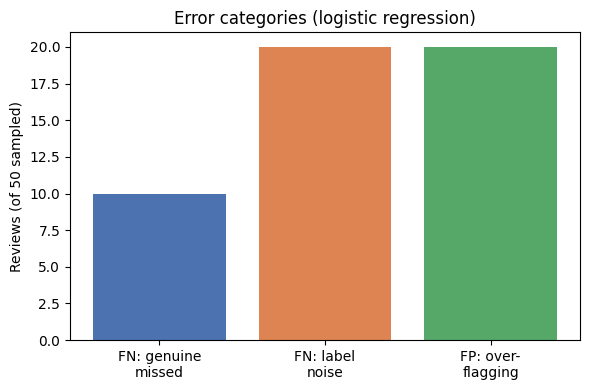

In [23]:
# Bar representation of Error Analysis Breakdown
import matplotlib.pyplot as plt
order = [("FN","genuine-missed"), ("FN","label noise"), ("FP","over-flagging")]
labels = ["FN: genuine\nmissed", "FN: label\nnoise", "FP: over-\nflagging"]
vals = [int(((ea.error==e) & (ea.bucket==b)).sum()) for e,b in order]

plt.figure(figsize=(6,4))
plt.bar(labels, vals, color=["#4c72b0", "#dd8452", "#55a868"])
plt.ylabel("Reviews (of 50 sampled)")
plt.title("Error categories (logistic regression)")
plt.tight_layout(); plt.savefig("fig_error_breakdown.png", dpi=150); plt.show()